c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())
C:\Users\Artur\AppData\Local\Temp\ipykernel_20876\900085703.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_precios, x='UnitPrice', y='ProductName', palette='viridis')


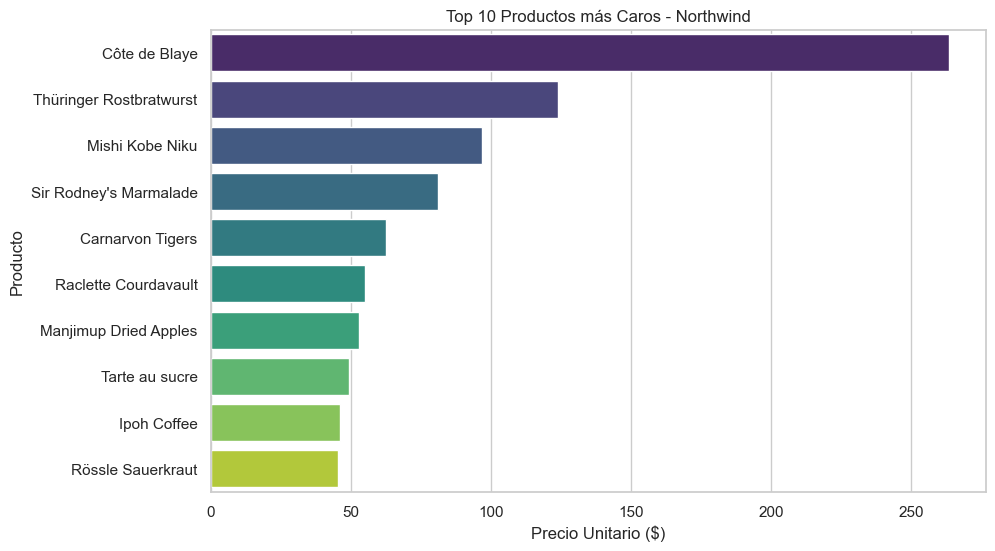

In [16]:
import sys
import os

# 1. Permitir que el Notebook encuentre la carpeta 'src'
sys.path.append(os.path.abspath('..'))

# 2. Imports profesionales
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.database import get_engine

# 3. Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 4. Cargar datos directamente de SQL para explorar
engine = get_engine()
query = """
SELECT TOP 10 ProductName, UnitPrice 
FROM Products 
ORDER BY UnitPrice DESC
"""
df_top_precios = pd.read_sql(query, engine)

# 5. Graficar con Seaborn
sns.barplot(data=df_top_precios, x='UnitPrice', y='ProductName', palette='viridis')
plt.title('Top 10 Productos más Caros - Northwind')
plt.xlabel('Precio Unitario ($)')
plt.ylabel('Producto')
plt.show()

'\n    SELECT \n        c.CategoryName,\n        SUM(od.UnitPrice * od.Quantity) as TotalRevenue\n    FROM Categories c\n    JOIN Products p ON c.CategoryID = p.CategoryID\n    JOIN [Order Details] od ON p.ProductID = od.ProductID\n    GROUP BY c.CategoryName\n    ORDER BY TotalRevenue DESC\n    '

In [8]:
from src.analytics import get_sales_by_category, get_monthly_sales

df_ventas = get_sales_by_category()
# ¡Y listo para graficar!
df_ss = get_monthly_sales()

df_ventas


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,CategoryName,TotalRevenue
0,Beverages,286526.95
1,Dairy Products,251330.50
2,Meat/Poultry,178188.80
3,Confections,177099.10
4,Seafood,141623.09
5,Condiments,113694.75
6,Produce,105268.60
7,Grains/Cereals,100726.80


In [7]:
df_ss

,Month,MonthlyRevenue
0,1996-07,30192.10
1,1996-08,26609.40
2,1996-09,27636.00
3,1996-10,41203.60
4,1996-11,49704.00
5,1996-12,50953.40
6,1997-01,66692.80
7,1997-02,41207.20
8,1997-03,39979.90
9,1997-04,55699.39


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,OrderID,OrderDate,ProductID,CustomerID,UnitPrice,Quantity,TotalAmount
0,10248,1996-07-04,11,VINET,14.0,12,168.0
1,10248,1996-07-04,42,VINET,9.8,10,98.0
2,10248,1996-07-04,72,VINET,34.8,5,174.0
3,10249,1996-07-05,14,TOMSP,18.6,9,167.4
4,10249,1996-07-05,51,TOMSP,42.4,40,1696.0


Text(0.5, 1.0, 'Tendencia Mensual de Ventas (Control Rápido)')

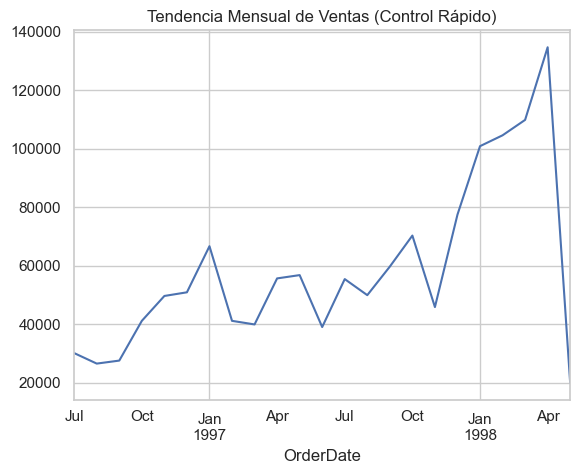

In [9]:
import sys
import os

# Sube un nivel para encontrar la carpeta raíz 'ANALISIS_VENTAS_NORTHWIND'
sys.path.append(os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.analytics import get_fact_sales

# Configuración de visualización
sns.set_theme(style="whitegrid")

# 1. Traer datos
df_ventas = get_fact_sales()

# 2. Ver tabla rápida
display(df_ventas.head())

# 3. Gráfico rápido de control (Ventas por Fecha)
df_ventas['OrderDate'] = pd.to_datetime(df_ventas['OrderDate'])
df_ventas.set_index('OrderDate')['TotalAmount'].resample('ME').sum().plot()
plt.title("Tendencia Mensual de Ventas (Control Rápido)")

In [ ]:
#import sys
#import os

# 1. Permitir que el Notebook encuentre la carpeta 'src'
#sys.path.append(os.path.abspath('..'))

# 2. Imports profesionales
import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt
from src.database import get_engine

# 3. Configuración visual
#sns.set_theme(style="whitegrid")
#plt.rcParams['figure.figsize'] = (10, 6)

# 4. Cargar datos directamente de SQL para explorar
engine = get_engine()
query = """"
SELECT OrderID, ProductID, Quantity
FROM [Order Details];
"""

df = pd.read_sql(query, engine)
val_mean = df['Quantity'].mean()
val_median = df['Quantity'].median()
val_mode = df['Quantity'].mode()

print(val_mean)
print(val_median)
print(val_mode)


23.812993039443157
20.0
0    20
Name: Quantity, dtype: int64


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [24]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('../northwind_orders.csv')

# 2. Calculate Location Parameters
count_val = df['Quantity'].count()
mean_val = df['Quantity'].mean()
median_val = df['Quantity'].median()
mode_val = df['Quantity'].mode()[0] # .mode() returns a Series, so we take the first index

print(f"--- Quantity Analysis ---")
print(f"Count Quantity:   {count_val}")
print(f"Mean Quantity:   {mean_val:.2f}")
print(f"Median Quantity: {median_val}")
print(f"Mode Quantity:   {mode_val}")

# 3. Quick Insight: Percentiles
# This shows us the 'spread' around the median
print(f"\n25th Percentile: {df['Quantity'].quantile(0.25)}")
print(f"50th Percentile: {df['Quantity'].quantile(0.50)}")
print(f"75th Percentile: {df['Quantity'].quantile(0.75)}")

--- Quantity Analysis ---
Count Quantity:   2155
Mean Quantity:   23.81
Median Quantity: 20.0
Mode Quantity:   20

25th Percentile: 10.0
50th Percentile: 20.0
75th Percentile: 30.0


In [41]:
import pandas as pd
from src.database import get_engine

engine = get_engine()
query = """SELECT OrderID, ProductID, Quantity
FROM [Order Details];"""

df = pd.read_sql(query, engine)
print(df.info())
print(df.head())

val_count = df['Quantity'].count()
val_mean = df['Quantity'].mean()
val_median = df['Quantity'].median()
val_mode = df['Quantity'].mode()

print(f"\nCount: {val_count}")
print(f"Mean: {val_mean:.2f}")
print(f"Median: {val_median}")
print(f"Mode: {val_mode}")

val_25th = df['Quantity'].quantile(0.25)
val_50th = df['Quantity'].quantile(0.50)
val_75th = df['Quantity'].quantile(0.75)

print(f"\n25th Quantile: {val_25th}")
print(f"50th Quantile: {val_50th}")
print(f"75th Quantile: {val_75th}")


print(f"95th Quantile: {df['Quantity'].quantile(0.95)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   OrderID    2155 non-null   int64
 1   ProductID  2155 non-null   int64
 2   Quantity   2155 non-null   int64
dtypes: int64(3)
memory usage: 50.6 KB
None
   OrderID  ProductID  Quantity
0    10248         11        12
1    10248         42        10
2    10248         72         5
3    10249         14         9
4    10249         51        40

Count: 2155
Mean: 23.81
Median: 20.0
Mode: 0    20
Name: Quantity, dtype: int64

25th Quantile: 10.0
50th Quantile: 20.0
75th Quantile: 30.0
95th Quantile: 60.0


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [42]:
import pandas as pd

df = pd.read_csv('../northwind_orders.csv')
print(df.info())
print(df.head())

val_count = df['Quantity'].count()
val_mean = df['Quantity'].mean()
val_median = df['Quantity'].median()
val_mode = df['Quantity'].mode()

print(f"\nCount: {val_count}")
print(f"Mean: {val_mean:.2f}")
print(f"Median: {val_median}")
print(f"Mode: {val_mode}")

val_25th = df['Quantity'].quantile(0.25)
val_50th = df['Quantity'].quantile(0.50)
val_75th = df['Quantity'].quantile(0.75)

print(f"\n25th Quantile: {val_25th}")
print(f"50th Quantile: {val_50th}")
print(f"75th Quantile: {val_75th}")


print(f"95th Quantile: {df['Quantity'].quantile(0.95)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   OrderID    2155 non-null   int64
 1   ProductID  2155 non-null   int64
 2   Quantity   2155 non-null   int64
dtypes: int64(3)
memory usage: 50.6 KB
None
   OrderID  ProductID  Quantity
0    10248         11        12
1    10248         42        10
2    10248         72         5
3    10249         14         9
4    10249         51        40

Count: 2155
Mean: 23.81
Median: 20.0
Mode: 0    20
Name: Quantity, dtype: int64

25th Quantile: 10.0
50th Quantile: 20.0
75th Quantile: 30.0
95th Quantile: 60.0


In [17]:
import pandas as pd
from src.database import get_engine

engine = get_engine()
query = """
select ProductID, Quantity from [Order Details]
where ProductID = 24;"""

df = pd.read_sql(query, engine)
print(df.info())
print(df.head())

val_count = df['Quantity'].count()
val_mean = df['Quantity'].mean()
val_median = df['Quantity'].median()
val_mode = df['Quantity'].mode()

print(f"\nCount: {val_count}")
print(f"Mean: {val_mean:.2f}")
print(f"Median: {val_median}")
print(f"Mode: {val_mode}")

val_25th = df['Quantity'].quantile(0.25)
val_50th = df['Quantity'].quantile(0.50)
val_75th = df['Quantity'].quantile(0.75)

print(f"\n25th Quantile: {val_25th}")
print(f"50th Quantile: {val_50th}")
print(f"75th Quantile: {val_75th}")


print(f"95th Quantile: {df['Quantity'].quantile(0.95)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  51 non-null     int64
 1   Quantity   51 non-null     int64
dtypes: int64(2)
memory usage: 948.0 bytes
None
   ProductID  Quantity
0         24        15
1         24        28
2         24        12
3         24        12
4         24         6

Count: 51
Mean: 22.06
Median: 15.0
Mode: 0    10
Name: Quantity, dtype: int64

25th Quantile: 10.0
50th Quantile: 15.0
75th Quantile: 26.5
95th Quantile: 60.0


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [3]:
import yfinance as yf

# This returns a Pandas DataFrame immediately
df = yf.download("AAPL", start="2024-01-01") 

print(df.tail()) # Shows the most recent trading days

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-27  258.269989  261.950012  258.209991  259.170013  49648300
2026-01-28  256.440002  258.859985  254.509995  257.649994  41288000
2026-01-29  258.279999  259.649994  254.410004  258.000000  67253000
2026-01-30  259.480011  261.899994  252.179993  255.169998  92443400
2026-02-02  270.010010  270.489990  259.209991  260.029999  73913400


In [21]:
import pandas as pd

from src.database import get_engine

from src.analytics import get_sales_by_category


df = get_sales_by_category()
print(df.head())

     CategoryName  TotalRevenue
0       Beverages     286526.95
1  Dairy Products     251330.50
2    Meat/Poultry     178188.80
3     Confections     177099.10
4         Seafood     141623.09


c:\Users\Artur\anaconda3\envs\newDemo\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [22]:
import pandas as pd
from src.database import get_engine, run_query

query = """
select ProductID, Quantity from [Order Details]
where ProductID = 24;"""
engine = run_query(query)

df = engine
print(df.info())
print(df.head())

val_count = df['Quantity'].count()
val_mean = df['Quantity'].mean()
val_median = df['Quantity'].median()
val_mode = df['Quantity'].mode()

print(f"\nCount: {val_count}")
print(f"Mean: {val_mean:.2f}")
print(f"Median: {val_median}")
print(f"Mode: {val_mode}")

val_25th = df['Quantity'].quantile(0.25)
val_50th = df['Quantity'].quantile(0.50)
val_75th = df['Quantity'].quantile(0.75)

print(f"\n25th Quantile: {val_25th}")
print(f"50th Quantile: {val_50th}")
print(f"75th Quantile: {val_75th}")


print(f"95th Quantile: {df['Quantity'].quantile(0.95)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  51 non-null     int64
 1   Quantity   51 non-null     int64
dtypes: int64(2)
memory usage: 948.0 bytes
None
   ProductID  Quantity
0         24        15
1         24        28
2         24        12
3         24        12
4         24         6

Count: 51
Mean: 22.06
Median: 15.0
Mode: 0    10
Name: Quantity, dtype: int64

25th Quantile: 10.0
50th Quantile: 15.0
75th Quantile: 26.5
95th Quantile: 60.0


d:\conda\Analisis_Ventas_Northwind\src\database.py:22: SAWarning: Unrecognized server version info '17.0.1050.2'.  Some SQL Server features may not function properly.
  with engine.connect() as conn:
